In [1]:
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np

import os
import json
import pandas as pd

In [2]:
home = os.environ.get("HOME")
# Set the folder containing the JSON files
folder_path = f"{home}/transfer/gitrepos/clonscal/thermalization/unmod_sim_data/250301"

In [3]:
import numpy as np
from scipy.integrate import quad
from numba import jit

# define obs that vanishes wrt rho
def n_moment_dse(x, order, sigma, lamb):
    return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

def n_moment(x, order):
    return x**order


# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

@jit
def R(x, r, a): return r*np.exp(-a*x**2/2)

@jit
def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_rho_tilde(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_R(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

# define exp val of n_moment_dse wrt rho_tilde
@np.vectorize
def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
    real_part, _ = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)
    imag_part, _ = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)
    
# define exp val of n_moment_dse wrt rho
@np.vectorize
def n_moment_dse_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

# define exp val of n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    
    out = real_part + 1j*imag_part
    return out / z_R(r, a, sigma, lamb)

     
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

@np.vectorize
def n_moment_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)

@np.vectorize
def n_moment_R(order, r, a):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, 0, 0)

In [4]:

# List all JSON files in the folder
json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

# Initialize a list to store data
data_list = []

# Loop through the JSON files and load them into a DataFrame
for file in json_files:
    file_path = os.path.join(folder_path, file)

    with open(file_path, "r") as f:
        data = json.load(f)
    
    # Flatten the structure
    flattened_data = {
        "steps": data["params"]["steps"],
        "mean_dS_max": data["params"]["mean_dS_max"],
        "trajs": data["params"]["trajs"],
        "dt": data["params"]["dt"],
        "sigma_abs": data["params"]["sigma_abs"],
        "sigma_phase": data["params"]["sigma_phase"],
        "lambda_abs": data["params"]["lambda_abs"],
        "bins_u": data["params"]["bins_u"],
        "bins_p": data["params"]["bins_p"],
        "p_min_real": data["params"]["p_min_real"],
        "p_max_real": data["params"]["p_max_real"],
        "p_min_imag": data["params"]["p_min_imag"],
        "p_max_imag": data["params"]["p_max_imag"],
        "u_min": data["params"]["u_min"],
        "u_max": data["params"]["u_max"],
        "key": file.split(".json")[0],
    }
    
    # Add moment values
    for moment in ["1_moment", "2_moment", "3_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]
    
    # Add dse moment values
    for moment in ["dse_1_moment", "dse_2_moment", "dse_3_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]
    
    data_list.append(flattened_data)

# Create the DataFrame
df = pd.DataFrame(data_list)

# rounding
df.keys()

Index(['steps', 'mean_dS_max', 'trajs', 'dt', 'sigma_abs', 'sigma_phase',
       'lambda_abs', 'bins_u', 'bins_p', 'p_min_real', 'p_max_real',
       'p_min_imag', 'p_max_imag', 'u_min', 'u_max', 'key',
       '1_moment_mean_real', '1_moment_mean_imag', '1_moment_sem_real',
       '1_moment_sem_imag', '1_moment_thermal_time', '1_moment_auto_corr',
       '2_moment_mean_real', '2_moment_mean_imag', '2_moment_sem_real',
       '2_moment_sem_imag', '2_moment_thermal_time', '2_moment_auto_corr',
       '3_moment_mean_real', '3_moment_mean_imag', '3_moment_sem_real',
       '3_moment_sem_imag', '3_moment_thermal_time', '3_moment_auto_corr',
       'dse_1_moment_mean_real', 'dse_1_moment_mean_imag',
       'dse_1_moment_sem_real', 'dse_1_moment_sem_imag',
       'dse_1_moment_thermal_time', 'dse_1_moment_auto_corr',
       'dse_2_moment_mean_real', 'dse_2_moment_mean_imag',
       'dse_2_moment_sem_real', 'dse_2_moment_sem_imag',
       'dse_2_moment_thermal_time', 'dse_2_moment_auto_corr',


In [5]:
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

from collections import defaultdict
histograms = defaultdict(dict)

for file in npy_files:
    hist_name = file.split(".")[0]
    key = "_".join(hist_name.split("_")[:3])
    obs_name = hist_name.split(key+"_")[-1]
    file_path = os.path.join(folder_path, file)
    dat = np.load(file_path)
    histograms[key][obs_name] = dat

In [6]:
# load .npz files (histograms)
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npz")]
histories = defaultdict(dict)

for file in npy_files:
    hist_name = file.split(".")[0]
    key = "_".join(hist_name.split("_")[:3])
    obs_name = hist_name.split(key+"_")[-1]
    file_path = os.path.join(folder_path, file)
    dat = np.load(file_path)
    histories[key][obs_name] = dat

### Plot thermalization of second moment

In [7]:
relevant_params = [
    "steps", 
    "mean_dS_max", 
    "trajs", 
    "dt", 
    "sigma_abs", 
    "sigma_phase", 
    "lambda_abs", 
    "bins_u", 
    "bins_p", 
    "p_min_real", 
    "p_max_real", 
    "p_min_imag", 
    "p_max_imag", 
    "u_min",
    "u_max"
]

In [8]:
for _, group in df.groupby(relevant_params):
    if len(group) >1: 
        print(group["key"])
        print()

In [11]:
print(lang_time.max())

31.794441


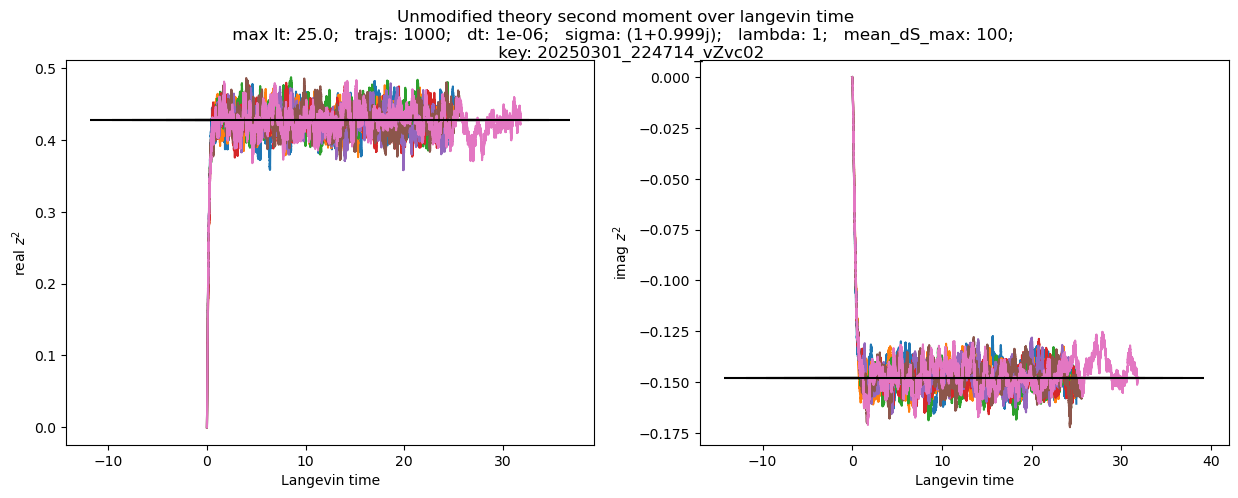

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex="col")
ax = ax.flatten()

for key, key_group in df.groupby("key"):
    steps = np.round(key_group["steps"].values[0], 3)
    trajs = np.round(key_group["trajs"].values[0], 3)
    dt = key_group["dt"].values[0]
    sigma_abs = np.round(key_group["sigma_abs"].values[0], 3)
    sigma_phase = np.round(key_group["sigma_phase"].values[0], 3)
    lambda_abs = np.round(key_group["lambda_abs"].values[0], 3)
    mean_dS_max = np.round(key_group["mean_dS_max"].values[0], 3)
    sigma = np.round(sigma_abs*np.exp(1j*sigma_phase), 3)
    max_lt = np.round(dt*steps, 3)
    title = f"Unmodified theory second moment over langevin time \n max lt: {max_lt};   trajs: {trajs};   dt: {dt};   sigma: {sigma};   lambda: {lambda_abs};   mean_dS_max: {mean_dS_max};   \n key: {key}"
    
    history = histories[key]
    lang_time = history["2_moment"]["meas_times"]
    dat = history["2_moment"]["result"]

    ax[0].plot(lang_time, dat.real)
    ax[1].plot(lang_time, dat.imag)

    fig.suptitle(title)
    ax[0].set_xlabel("Langevin time")
    ax[1].set_xlabel("Langevin time")
    ax[0].set_ylabel(rf"real $z^2$")
    ax[1].set_ylabel(rf"imag $z^2$")

    ana = n_moment_rho(2, sigma, lambda_abs)
    xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
    ax[0].hlines(ana.real, *xlim, color = "black")
    xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
    ax[1].hlines(ana.imag, *xlim, color = "black")

    # meas_time = history["2_moment"]["meas_time"]
    # histogr = histograms[key]
    # history = history["2_moment"]
    # plt.plot(history["meas_times"], history["result"])

Error in callback <function _draw_all_if_interactive at 0x7ffb72f30c10> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

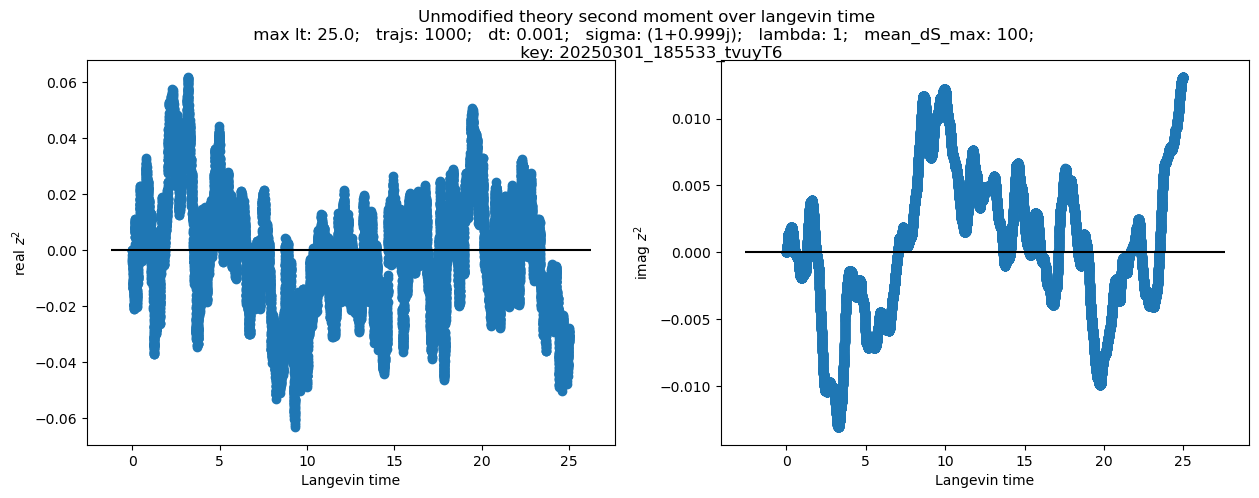

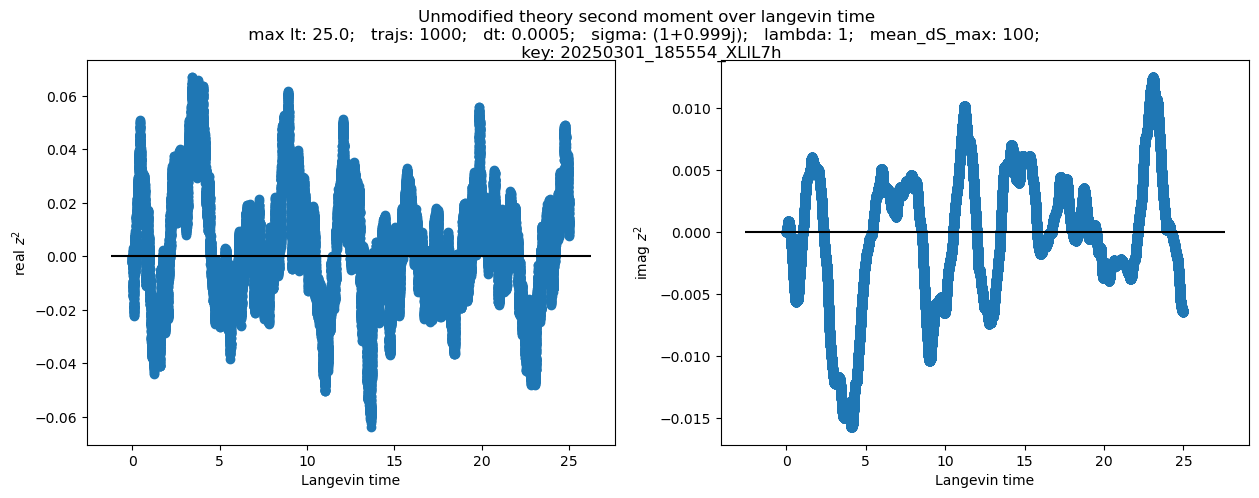

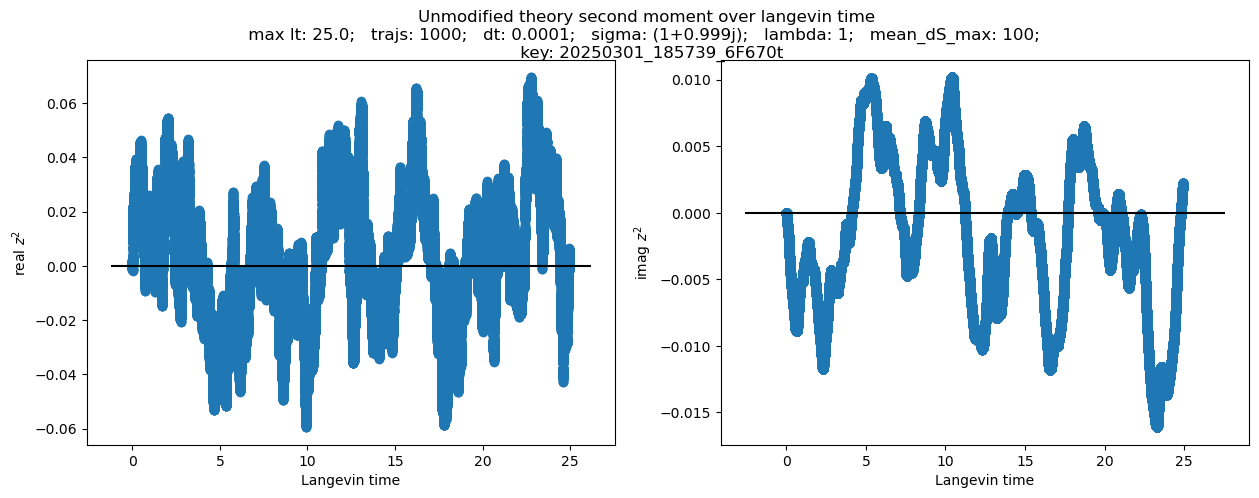

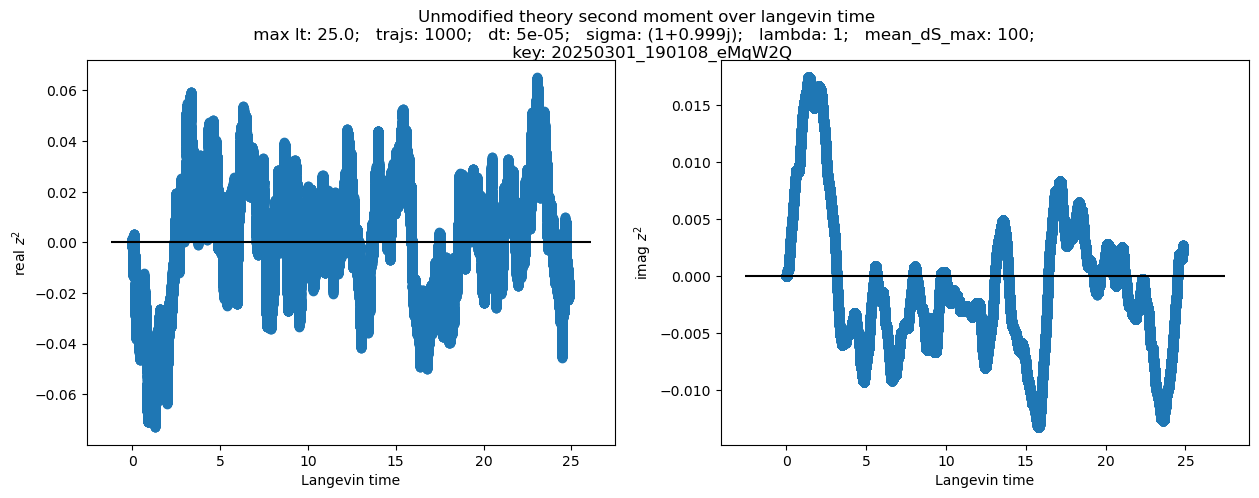

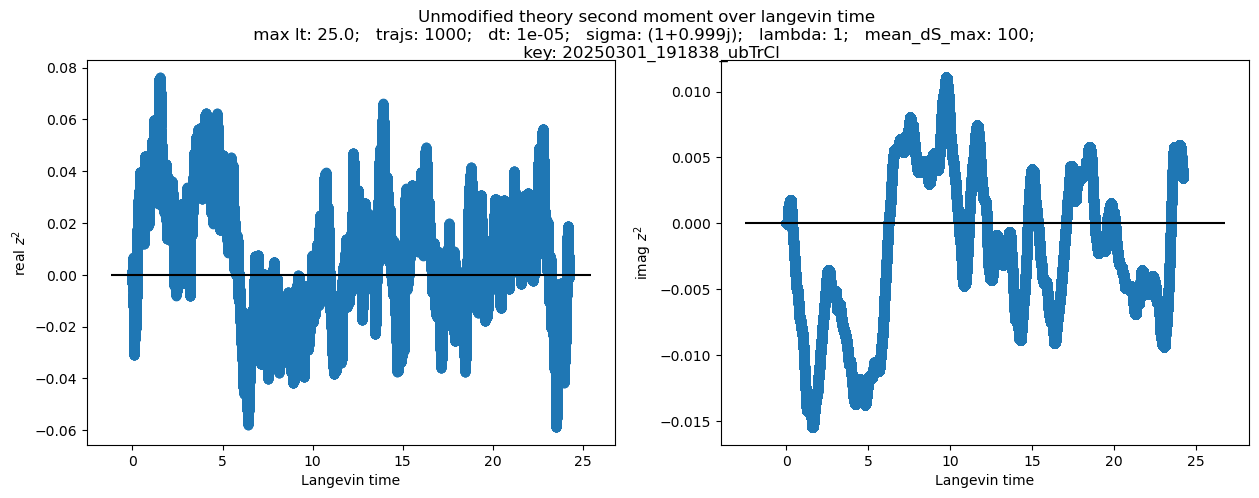

In [ ]:
for key, key_group in df.groupby("key"):
    steps = np.round(key_group["steps"].values[0], 3)
    trajs = np.round(key_group["trajs"].values[0], 3)
    dt = key_group["dt"].values[0]
    sigma_abs = np.round(key_group["sigma_abs"].values[0], 3)
    sigma_phase = np.round(key_group["sigma_phase"].values[0], 3)
    lambda_abs = np.round(key_group["lambda_abs"].values[0], 3)
    mean_dS_max = np.round(key_group["mean_dS_max"].values[0], 3)
    sigma = np.round(sigma_abs*np.exp(1j*sigma_phase), 3)
    max_lt = np.round(dt*steps, 3)
    title = f"Unmodified theory second moment over langevin time \n max lt: {max_lt};   trajs: {trajs};   dt: {dt};   sigma: {sigma};   lambda: {lambda_abs};   mean_dS_max: {mean_dS_max};   \n key: {key}"
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex="col")
    ax = ax.flatten()
    history = histories[key]
    lang_time = history["1_moment"]["meas_times"]
    dat = history["1_moment"]["result"]
    ax[0].scatter(lang_time, dat.real)
    ax[1].scatter(lang_time, dat.imag)

    fig.suptitle(title)
    ax[0].set_xlabel("Langevin time")
    ax[1].set_xlabel("Langevin time")
    ax[0].set_ylabel(rf"real $z^2$")
    ax[1].set_ylabel(rf"imag $z^2$")

    ana = n_moment_rho(1, sigma, lambda_abs)
    xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
    ax[0].hlines(ana.real, *xlim, color = "black")
    xlim, ylim = ax[0].get_xlim(), ax[0].get_ylim()
    ax[1].hlines(ana.imag, *xlim, color = "black")